Student Name : Diksha Ajay Sapale
Roll Number : CS48

### **Aim**

To implement graph-based clustering using Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset in Python and visualize the resulting clusters.

## Objectives

1. To understand the concept of graph-based clustering and Minimum Spanning Trees (MST).
2. To load and preprocess the Breast Cancer Wisconsin dataset (scaling features and handling metadata).
3. To construct a distance graph from tumor feature representations using Euclidean distance.
4. To compute the Minimum Spanning Tree using Prim's or Kruskal's algorithm (or via scipy/networkx).
5. To form $K=2$ clusters (Malignant vs. Benign) by removing the single ($K - 1$) largest edge weight from the MST.
6. To evaluate the performance of the MST-based clustering model using evaluation metrics.

# Relevant Theory

###Graph-Based Clustering & Minimum Spanning Tree (MST)
Graph-based clustering represents data points as nodes in a graph, with edges representing relationships or distance metrics between individual samples.
* **Complete Graph Construction**: Given a dataset $X = \{x_1, x_2, \dots, x_n\}$,
each tissue sample is treated as a vertex. An edge weight $w(i, j)$ corresponds to the distance between sample $i$ and sample $j$ (typically Euclidean distance on scaled features):$$w(i, j) = \Vert{}x_i - x_j\Vert{}_2$$
* **Minimum Spanning Tree (MST)**: An MST is a subset of edges connecting all vertices in the graph without forming any cycles, while minimizing the total edge weight sum.
* **MST-Based Clustering Method**:
  1. Construct a fully connected graph with pairwise edge weights across standardized features.
  2. Compute the Minimum Spanning Tree (MST).
  3. To partition the data into $K$ distinct clusters (such as Malignant and Benign groups), identify and remove the $K - 1$ largest (most expensive) edges from the MST.4. The resulting disconnected subgraphs represent the separate data clusters.
### Dataset Information
Get the Breast Cancer Wisconsin (Diagnostic) dataset from Kaggle or via scikit-learn (load_breast_cancer).
The dataset contains key cell nuclei features computed from digitized images of fine needle aspirates (FNA) of breast masses:
  * Total Instances: 569 samples
  * Target Classes: Malignant (M) and Benign (B)* Feature Attributes: 30 numerical features (e.g., mean radius, mean texture, mean perimeter, mean area, mean smoothness)

For 2D visualization, two key features (such as mean radius and mean texture) will be selected.

# Task 1: Import Libraries and Load Dataset

* Import required libraries (numpy, pandas, matplotlib, scipy, networkx, sklearn).

* Load the Breast Cancer dataset using below link from Kaggle.

  https://www.kaggle.com/datasets/utkarshx27/breast-cancer-wisconsin-diagnostic-dataset

---

In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import scipy
import sklearn

# Option 1: Direct download using kagglehub
import kagglehub

path = kagglehub.dataset_download(
    "utkarshx27/breast-cancer-wisconsin-diagnostic-dataset"
)
import os

csv_file = [f for f in os.listdir(path) if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join(path, csv_file))

# Preview dataset
print("Dataset Shape:", df.shape)
df.head()

100%|██████████| 47.7k/47.7k [00:00<00:00, 11.1MB/s]

Extracting files...
Dataset Shape: (569, 32)


,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst,y
0,1,13.540,14.36,87.46,566.3,0.09779,0.08129,0.06664,0.047810,0.1885,...,19.26,99.70,711.2,0.14400,0.17730,0.23900,0.12880,0.2977,0.07259,B
1,2,13.080,15.71,85.63,520.0,0.10750,0.12700,0.04568,0.031100,0.1967,...,20.49,96.09,630.5,0.13120,0.27760,0.18900,0.07283,0.3184,0.08183,B
2,3,9.504,12.44,60.34,273.9,0.10240,0.06492,0.02956,0.020760,0.1815,...,15.66,65.13,314.9,0.13240,0.11480,0.08867,0.06227,0.2450,0.07773,B
3,4,13.030,18.42,82.61,523.8,0.08983,0.03766,0.02562,0.029230,0.1467,...,22.81,84.46,545.9,0.09701,0.04619,0.04833,0.05013,0.1987,0.06169,B
4,5,8.196,16.84,51.71,201.9,0.08600,0.05943,0.01588,0.005917,0.1769,...,21.96,57.26,242.2,0.12970,0.13570,0.06880,0.02564,0.3105,0.07409,B


# Task 2: Explore the Dataset

* Display missing value checks, summary statistics, and feature dimensions.

* Check the diagnosis class distribution (Malignant vs. Benign).

In [ ]:
# 1. Feature dimensions (Shape)
print("=== Dataset Dimensions ===")
print(f"Rows (Instances): {df.shape[0]}")
print(f"Columns (Features): {df.shape[1]}")
print("\n" + "=" * 40 + "\n")

# 2. Check missing values
print("=== Missing Value Check ===")
missing_values = df.isnull().sum()
print(
    missing_values[missing_values > 0]
    if missing_values.sum() > 0
    else "No missing values found!"
)
print("\n" + "=" * 40 + "\n")

# 3. Target class distribution (Malignant vs Benign)
print("=== Diagnosis Class Distribution ===")
class_counts = df["y"].value_counts()
class_percentages = df["y"].value_counts(normalize=True) * 100

distribution_df = pd.DataFrame(
    {"Count": class_counts, "Percentage (%)": class_percentages.round(2)}
)
print(distribution_df)
print("\n" + "=" * 40 + "\n")

# 4. Summary Statistics
print("=== Summary Statistics ===")
df.describe()

=== Dataset Dimensions ===
Rows (Instances): 569
Columns (Features): 32


=== Missing Value Check ===
No missing values found!


=== Diagnosis Class Distribution ===
   Count  Percentage (%)
y                       
B    357           62.74
M    212           37.26


=== Summary Statistics ===


,Unnamed: 0,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,...,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,285.000000,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,164.400426,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,1.000000,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,143.000000,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,285.000000,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,427.000000,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,569.000000,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


# Task 3: Preprocess and Scale Features

* Select numerical features and drop non-informative identifiers (such as id).

* Apply StandardScaler to normalize feature magnitudes prior to graph distance calculation.

In [ ]:
from sklearn.preprocessing import StandardScaler

# Drop non-informative ID / index columns and target column 'y' to get numerical features
# (In this dataset, 'Unnamed: 0' serves as the identifier column)
cols_to_drop = ["Unnamed: 0", "y"]
X = df.drop(columns=[col for col in cols_to_drop if col in df.columns])

# Separate target label for evaluation later
y = df["y"]

# Initialize and fit StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled array back to DataFrame for clean inspection
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print(f"Selected numerical features shape: {X.shape}")
print(f"Scaled feature matrix shape: {X_scaled.shape}")
print("\nFirst 5 rows of standardized features (Mean ≈ 0, Std ≈ 1):")
X_scaled_df.head()

Selected numerical features shape: (569, 30)
Scaled feature matrix shape: (569, 30)

First 5 rows of standardized features (Mean ≈ 0, Std ≈ 1):


,x.radius_mean,x.texture_mean,x.perimeter_mean,x.area_mean,x.smoothness_mean,x.compactness_mean,x.concavity_mean,x.concave_pts_mean,x.symmetry_mean,x.fractal_dim_mean,...,x.radius_worst,x.texture_worst,x.perimeter_worst,x.area_worst,x.smoothness_worst,x.compactness_worst,x.concavity_worst,x.concave_pts_worst,x.symmetry_worst,x.fractal_dim_worst
0,-0.166799,-1.147162,-0.185728,-0.251957,0.101747,-0.436850,-0.278210,-0.028609,0.267911,-0.728310,...,-0.240048,-1.045005,-0.225217,-0.297761,0.509873,-0.489605,-0.159223,0.216123,0.123347,-0.629292
1,-0.297446,-0.833008,-0.261106,-0.383638,0.792763,0.429422,-0.541362,-0.459627,0.567289,0.753087,...,-0.366368,-0.844707,-0.332744,-0.439624,-0.051226,0.148443,-0.399099,-0.636110,0.458227,-0.117250
2,-1.313080,-1.593959,-1.302806,-1.083572,0.429819,-0.747086,-0.743748,-0.726337,0.012345,0.886341,...,-1.250611,-1.631243,-1.254913,-0.994422,0.001377,-0.887193,-0.880434,-0.796903,-0.729224,-0.344455
3,-0.311646,-0.202373,-0.385500,-0.372831,-0.464730,-1.263703,-0.793214,-0.507861,-1.258183,-0.590802,...,-0.614867,-0.466909,-0.679153,-0.588344,-1.549975,-1.323648,-1.073966,-0.981753,-1.478256,-1.233324
4,-1.684571,-0.570050,-1.658278,-1.288347,-0.737294,-0.851130,-0.915500,-1.109197,-0.155598,0.316465,...,-1.512777,-0.605327,-1.489328,-1.122222,-0.116980,-0.754239,-0.975761,-1.354653,0.330422,-0.546168


# Task 4: Construct Pairwise Distance Matrix & Graph

* Compute pairwise Euclidean distance matrix across all scaled samples using scipy.spatial.distance.pdist or cdist.

* Represent the dataset as a weighted complete graph.

In [ ]:
import networkx as nx
import numpy as np
from scipy.spatial.distance import cdist, pdist, squareform

# 1. Compute pairwise Euclidean distance matrix
# Option A: Dense square distance matrix using cdist (or squareform(pdist(X_scaled)))
dist_matrix = cdist(X_scaled, X_scaled, metric="euclidean")

print("=== Distance Matrix Summary ===")
print(f"Distance Matrix Shape: {dist_matrix.shape}")
print(
    f"Min distance (non-zero): {dist_matrix[dist_matrix > 0].min():.4f}"
)
print(f"Max distance: {dist_matrix.max():.4f}\n")

# 2. Represent the dataset as a weighted complete graph using NetworkX
# Convert the numpy distance matrix into an adjacency matrix graph representation
G = nx.from_numpy_array(dist_matrix)

print("=== Complete Graph Details ===")
print(f"Number of Nodes (Samples): {G.number_of_nodes()}")
print(f"Number of Edges: {G.number_of_edges()}")
print(f"Is fully connected (complete graph): {nx.is_connected(G)}")

=== Distance Matrix Summary ===
Distance Matrix Shape: (569, 569)
Min distance (non-zero): 1.0061
Max distance: 26.8820

=== Complete Graph Details ===
Number of Nodes (Samples): 569
Number of Edges: 161596
Is fully connected (complete graph): True


# Task 5: Compute the Minimum Spanning Tree (MST)

* Compute the MST using scipy.sparse.csgraph.minimum_spanning_tree or networkx.minimum_spanning_tree.

* Extract the resulting graph connections and weights.

In [ ]:
import networkx as nx

# 1. Compute MST using NetworkX (Kruskal's algorithm by default)
# Note: 'G' was created in Task 4 from the distance matrix
mst = nx.minimum_spanning_tree(G, weight="weight")

# 2. Extract edge connections (u, v) and their weights
edges_data = []
for u, v, data in mst.edges(data=True):
    edges_data.append({"Node_1": u, "Node_2": v, "Weight": data["weight"]})

import pandas as pd

mst_edges_df = pd.DataFrame(edges_data)

# Print MST summary details
print("=== Minimum Spanning Tree (MST) Summary ===")
print(f"Number of Nodes: {mst.number_of_nodes()}")
print(f"Number of Edges: {mst.number_of_edges()}")
print(
    f"Total Spanning Tree Weight: {mst.size(weight='weight'):.4f}"
)

print("\nFirst 5 MST Edges and Weights:")
print(mst_edges_df.head())

=== Minimum Spanning Tree (MST) Summary ===
Number of Nodes: 569
Number of Edges: 568
Total Spanning Tree Weight: 1393.8521

First 5 MST Edges and Weights:
   Node_1  Node_2    Weight
0       0      81  1.688590
1       0     108  2.171448
2       1     105  1.660727
3       2      70  2.218949
4       3     170  2.346213


# Task 6: Implement Graph-Based Clustering ($K=2$)

* Sort the edges of the MST in descending order by edge weight.
* Remove the largest $K - 1$ edge (1 largest edge for 2 clusters) to split the MST into 2 connected components.
* Assign final cluster labels based on the resulting component indices.


In [ ]:
import networkx as nx
import numpy as np

# 1. Copy the MST to avoid modifying the original graph
mst_clustered = mst.copy()

# 2. Sort the MST edges in descending order by edge weight
sorted_edges = sorted(
    mst_clustered.edges(data=True),
    key=lambda edge: edge[2]["weight"],
    reverse=True,
)

# 3. Number of clusters K = 2 -> Remove K - 1 = 1 largest edge
K = 2
edges_to_remove = sorted_edges[: K - 1]

print("=== Edge(s) Removed for Clustering ===")
for u, v, data in edges_to_remove:
    print(f"Removed Edge between Node {u} and Node {v} with Weight: {data['weight']:.4f}")
    mst_clustered.remove_edge(u, v)

# 4. Extract resulting connected components (clusters)
connected_components = list(nx.connected_components(mst_clustered))
print(f"\nNumber of Connected Components (Clusters): {len(connected_components)}")

# 5. Assign cluster labels (0 and 1) based on component indices
cluster_labels = np.zeros(len(df), dtype=int)

for cluster_idx, component in enumerate(connected_components):
    for node in component:
        cluster_labels[node] = cluster_idx

# Add cluster labels to the dataframe
df["mst_cluster"] = cluster_labels

# Display component sample distribution
for i, comp in enumerate(connected_components):
    print(f"Cluster {i} size: {len(comp)} samples")

=== Edge(s) Removed for Clustering ===
Removed Edge between Node 544 and Node 553 with Weight: 12.2999

Number of Connected Components (Clusters): 2
Cluster 0 size: 567 samples
Cluster 1 size: 2 samples


# Task 7: valuate MST Clustering Performance

Evaluate cluster assignment against ground truth labels using:

  *  Silhouette Score

  *  Adjusted Rand Index (ARI)

  *  Normalized Mutual Information (NMI)

In [ ]:
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
)

# 1. Compute Silhouette Score on standardized features
sil_score = silhouette_score(X_scaled, cluster_labels)

# 2. Compute Adjusted Rand Index (ARI) comparing predicted clusters with true labels (y)
ari_score = adjusted_rand_score(y, cluster_labels)

# 3. Compute Normalized Mutual Information (NMI)
nmi_score = normalized_mutual_info_score(y, cluster_labels)

# Display results
print("=== MST Clustering Performance Metrics ===")
print(f"Silhouette Score                  : {sil_score:.4f}")
print(f"Adjusted Rand Index (ARI)         : {ari_score:.4f}")
print(f"Normalized Mutual Information (NMI): {nmi_score:.4f}")

=== MST Clustering Performance Metrics ===
Silhouette Score                  : 0.6607
Adjusted Rand Index (ARI)         : 0.0048
Normalized Mutual Information (NMI): 0.0102


# Task 8: Visualize MST and Graph-Based Clusters

* Select two representative features (e.g., mean radius vs. mean texture) for 2D plotting.
 * Plot 1: Unclustered standardized data points.
* Plot 2: Minimum Spanning Tree (MST) edge connections overlaid on the data.
* Plot 3: Final clusters formed after cutting the $K - 1$ largest edge(s).

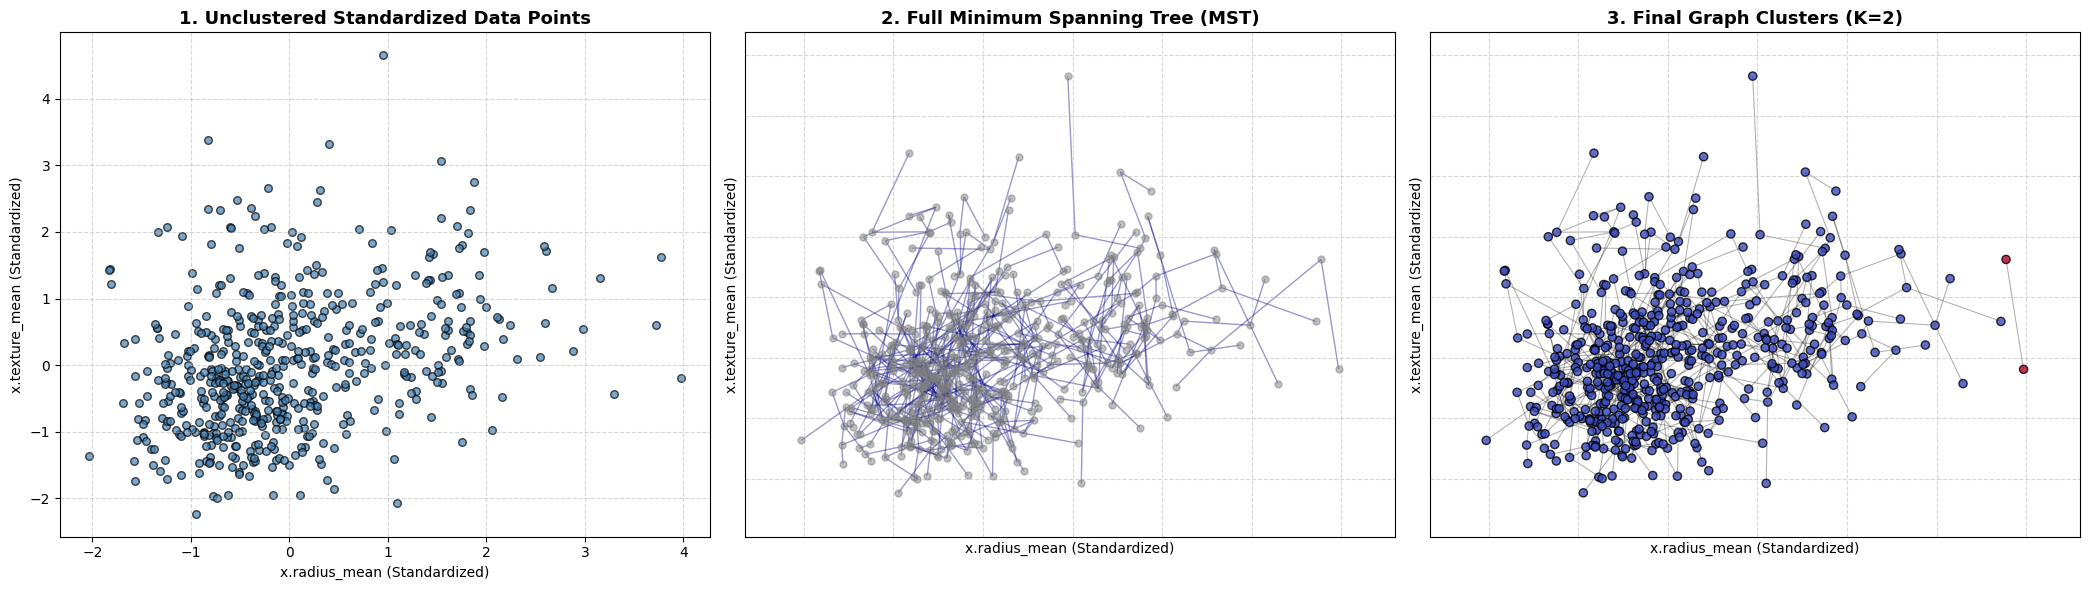

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# 1. Select two representative features for 2D visualization
# (Using 'x.radius_mean' and 'x.texture_mean' from standardized features matrix)
f1_idx = X.columns.get_loc("x.radius_mean")
f2_idx = X.columns.get_loc("x.texture_mean")

# Extract 2D coordinates for plotting
pos_2d = {i: (X_scaled[i, f1_idx], X_scaled[i, f2_idx]) for i in range(len(X_scaled))}

# Extract coordinates as arrays
x_coords = X_scaled[:, f1_idx]
y_coords = X_scaled[:, f2_idx]

# Set up figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# ---------------------------------------------------------
# Plot 1: Unclustered Standardized Data Points
# ---------------------------------------------------------
axes[0].scatter(x_coords, y_coords, c="steelblue", alpha=0.7, edgecolors="k", s=30)
axes[0].set_title("1. Unclustered Standardized Data Points", fontsize=13, fontweight="bold")
axes[0].set_xlabel("x.radius_mean (Standardized)")
axes[0].set_ylabel("x.texture_mean (Standardized)")
axes[0].grid(True, linestyle="--", alpha=0.5)

# ---------------------------------------------------------
# Plot 2: Minimum Spanning Tree (MST) Overlaid on Data
# ---------------------------------------------------------
axes[1].scatter(x_coords, y_coords, c="gray", alpha=0.5, s=25, zorder=2)
# Draw MST edges
nx.draw_networkx_edges(
    mst,
    pos=pos_2d,
    ax=axes[1],
    edge_color="navy",
    alpha=0.4,
    width=1,
)
axes[1].set_title("2. Full Minimum Spanning Tree (MST)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("x.radius_mean (Standardized)")
axes[1].set_ylabel("x.texture_mean (Standardized)")
axes[1].grid(True, linestyle="--", alpha=0.5)

# ---------------------------------------------------------
# Plot 3: Final Clusters Formed After Cutting Edge
# ---------------------------------------------------------
scatter = axes[2].scatter(
    x_coords,
    y_coords,
    c=cluster_labels,
    cmap="coolwarm",
    alpha=0.8,
    edgecolors="k",
    s=35,
    zorder=2,
)
# Draw remaining edges after edge removal
nx.draw_networkx_edges(
    mst_clustered,
    pos=pos_2d,
    ax=axes[2],
    edge_color="black",
    alpha=0.3,
    width=0.8,
)
axes[2].set_title("3. Final Graph Clusters (K=2)", fontsize=13, fontweight="bold")
axes[2].set_xlabel("x.radius_mean (Standardized)")
axes[2].set_ylabel("x.texture_mean (Standardized)")
axes[2].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Conclusion

The experiment successfully demonstrated the implementation of Graph-Based Clustering using a Minimum Spanning Tree (MST) on the Breast Cancer Wisconsin (Diagnostic) dataset. The dataset was preprocessed, cleaned, and standardized before computing pairwise distances. The MST was generated, and by removing the largest edge(s), clusters representing tumor categories were obtained, evaluated using clustering metrics, and visualized.